<a href="https://colab.research.google.com/github/vaouny-ux/vaouny-ux/blob/main/Copy_of_without_outliers_semi_final_copy_of_Weather_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Weather Classification Using Machine Learning**

---



  ### ***Introduction***

  In this project, we develop a weather classification system using a dataset containing meteorological features such as temperature, humidity, wind speed, precipitation, atmospheric pressure, UV index, visibility, cloud cover, season, and location. The objective is to predict the Weather Type (Rainy , Cloudy
 , Snowy
, Sunny) based on these features.

The project follows the complete machine learning workflow, including data preprocessing, exploratory data analysis (EDA), model development, and performance evaluation. Three classification algorithms are implemented and compared:

* Logistic Regression
* Gaussian Naive Bayes
* Support Vector Machine (SVM)

The main objectives of this project are:

* To preprocess and prepare the dataset for machine learning.
* To explore the dataset through statistical analysis and visualization.
* To build and train multiple classification models.
* To evaluate and compare the performance of different machine learning algorithms.
* To identify the most suitable model for accurate weather classification.


---



# 1. Data Collection & Preprocessing

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("weather_classification_data.csv")

In [ ]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [ ]:
df.shape

(13200, 11)

In [ ]:
df.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


In [ ]:
df.dtypes

,0
Temperature,float64
Humidity,int64
Wind Speed,float64
Precipitation (%),float64
Cloud Cover,object
Atmospheric Pressure,float64
UV Index,int64
Season,object
Visibility (km),float64
Location,object


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Weather Type"].value_counts()

,count
Weather Type,
Rainy,3300
Cloudy,3300
Sunny,3300
Snowy,3300


In [ ]:
numerical_columns = [
    "Temperature",
    "Humidity",
    "Wind Speed",
    "Precipitation (%)",
    "Atmospheric Pressure",
    "UV Index",
    "Visibility (km)"
]

In [ ]:
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df[numerical_columns] < lower_bound) |
    (df[numerical_columns] > upper_bound)
).any(axis=1)

print("Number of potential outliers:", outlier_mask.sum())

df_clean = df[~outlier_mask].copy()

print("Original dataset shape:", df.shape)
print("After removing outliers:", df_clean.shape)

Number of potential outliers: 1511
Original dataset shape: (13200, 11)
After removing outliers: (11689, 11)


In [ ]:
df_clean["Weather Type"].value_counts()

,count
Weather Type,
Cloudy,2994
Sunny,2965
Snowy,2902
Rainy,2828


In [ ]:
df_clean.shape

(11689, 11)

In [ ]:
X = df_clean.drop("Weather Type", axis=1)
y = df_clean["Weather Type"]

In [ ]:
X.select_dtypes(include="object").columns

Index(['Cloud Cover', 'Season', 'Location'], dtype='object')

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [ ]:
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))
print(mapping)

{'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)


In [ ]:
print(X_train_scaled.head())
print(y_train[:5])
print(X_test_scaled.head())
print(y_test[:5])
print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

      Temperature  Humidity  Wind Speed  Precipitation (%)  \
2309    -1.448703  1.410748    0.763661           0.772806   
1614    -0.569263  0.895449    0.585650           0.148747   
1451     0.875530  0.792390   -0.037388           0.055138   
8996    -0.757715  1.307688    1.920731           1.178444   
9170     0.435810 -1.320335   -1.461474          -1.255386   

      Atmospheric Pressure  UV Index  Visibility (km)  Cloud Cover_cloudy  \
2309             -1.465565 -1.003631        -0.610834           -0.072579   
1614             -1.020998 -0.170548        -0.037215           -0.072579   
1451              0.093516 -0.725937        -1.375661           -0.072579   
8996              1.013629  0.107146        -0.419628           -0.072579   
9170              1.428764  0.662534         0.345198           -0.072579   

      Cloud Cover_overcast  Cloud Cover_partly cloudy  Season_Spring  \
2309              1.061451                  -0.729863      -0.491933   
1614              1.

# 2. Exploratory Data Analysis (EDA) & Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use("ggplot")
sns.set(font_scale=1.1)

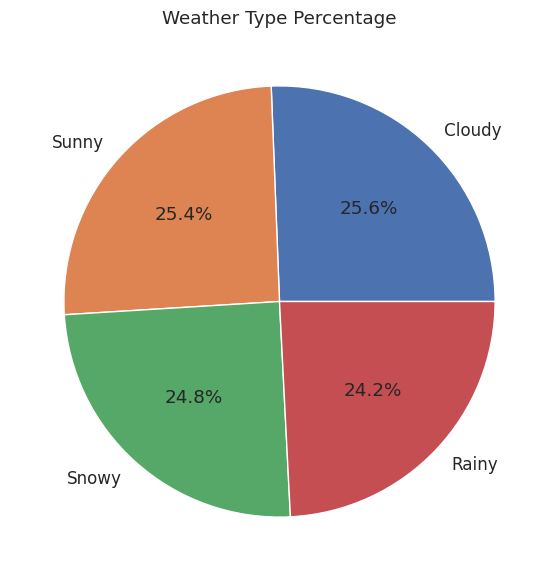

In [ ]:
weather_counts = df_clean["Weather Type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    weather_counts,
    labels=weather_counts.index,
    autopct="%1.1f%%"
)

plt.title("Weather Type Percentage")

plt.show()

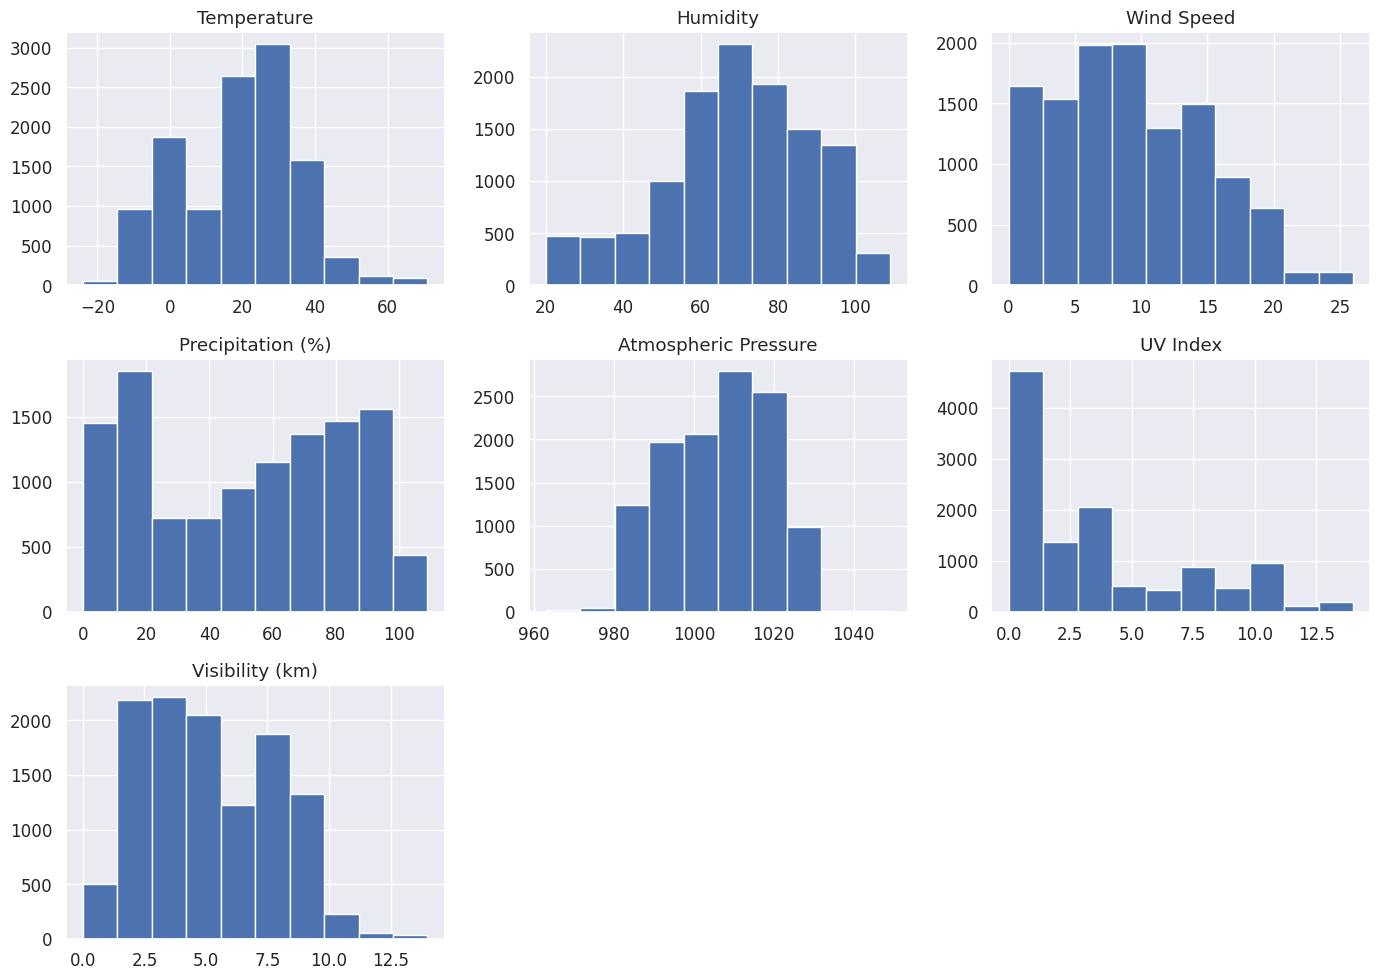

In [ ]:
df_clean[numerical_columns].hist(figsize=(14,10))

plt.tight_layout()

plt.show()

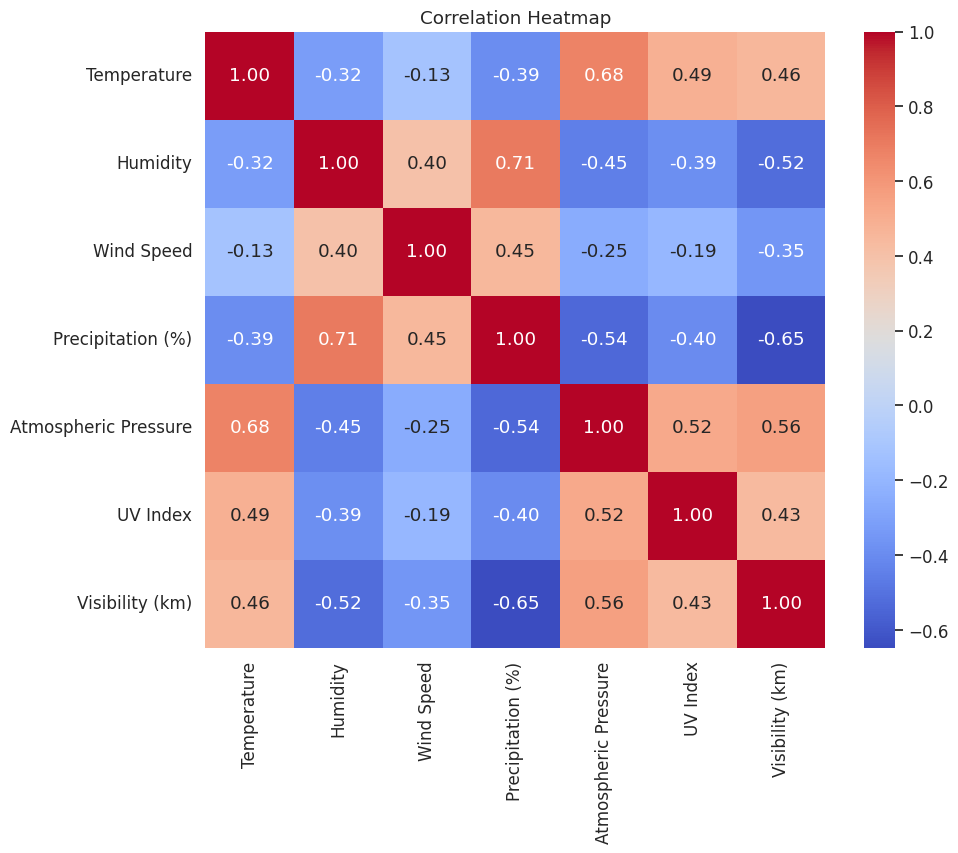

In [ ]:
plt.figure(figsize=(10,8))

corr = df_clean[numerical_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

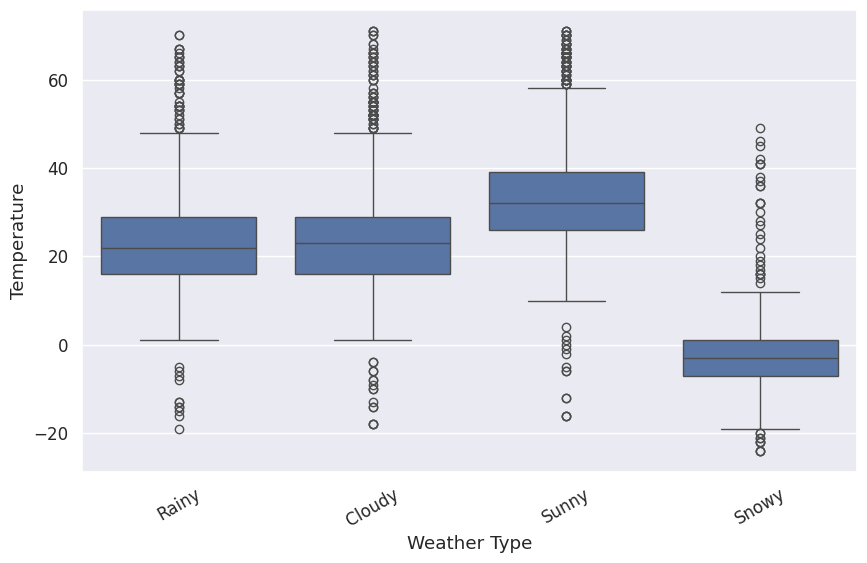

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x="Weather Type",
    y="Temperature"
)

plt.xticks(rotation=30)

plt.show()

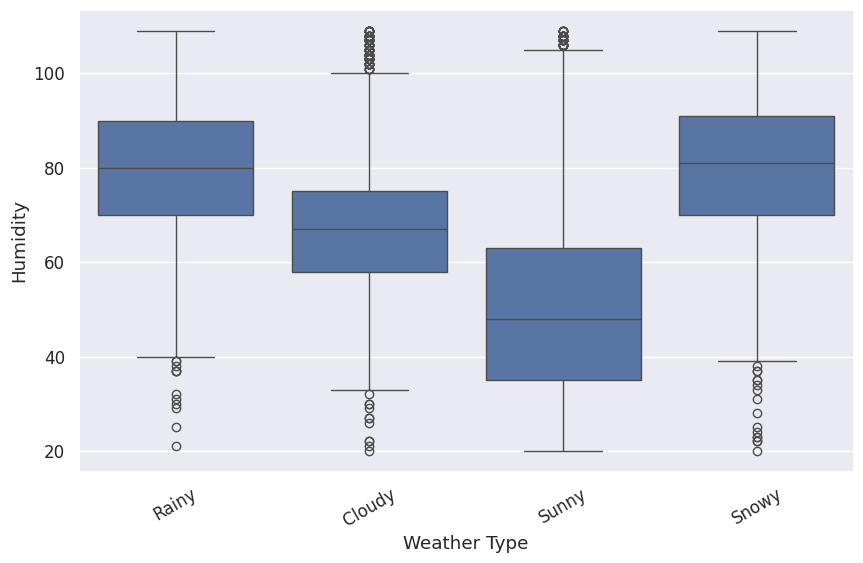

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x="Weather Type",
    y="Humidity"
)

plt.xticks(rotation=30)

plt.show()

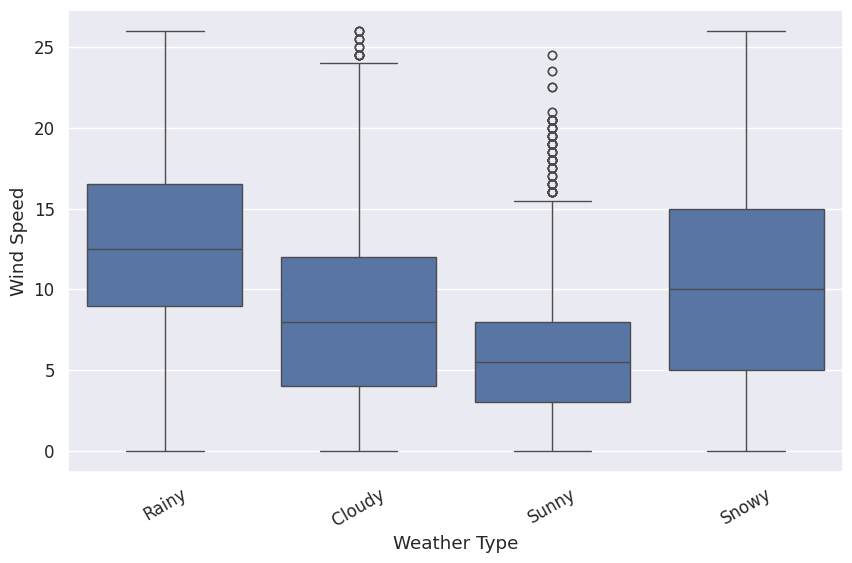

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x="Weather Type",
    y="Wind Speed"
)

plt.xticks(rotation=30)

plt.show()

In [ ]:
fig = px.scatter(
    df_clean,
    x="Temperature",
    y="Humidity",
    color="Weather Type",
    title="Temperature vs Humidity"
)

fig.show()

In [ ]:
fig = px.histogram(
    df_clean,
    x="Temperature",
    color="Weather Type",
    barmode="overlay"
)

fig.show()

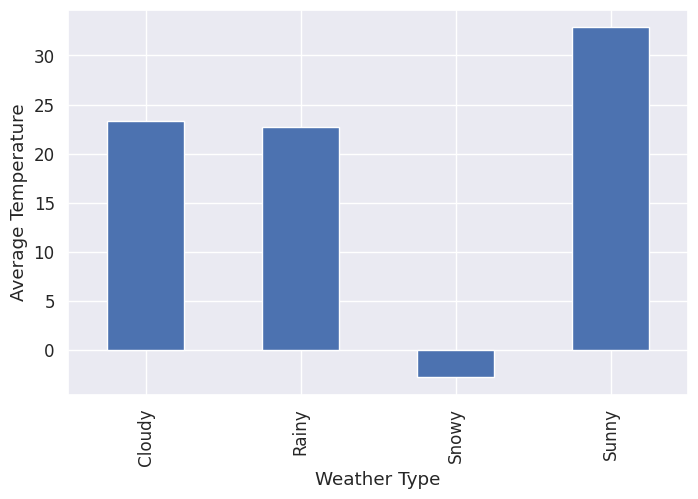

In [ ]:
avg_temp = df_clean.groupby("Weather Type")["Temperature"].mean()
avg_temp.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Average Temperature")

plt.show()

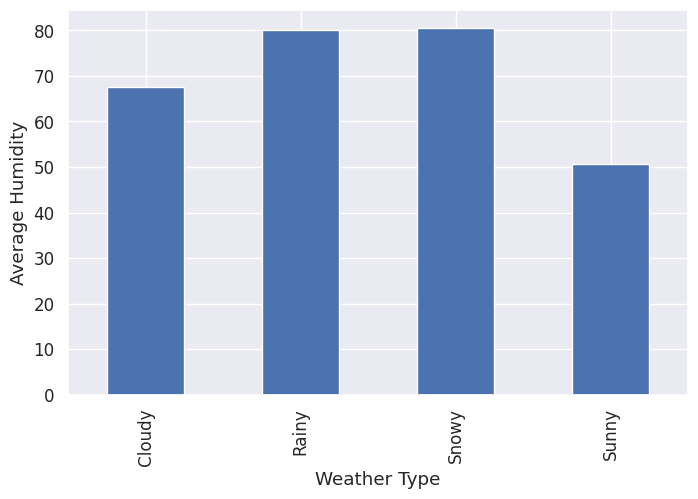

In [ ]:
avg_humidity = df_clean.groupby("Weather Type")["Humidity"].mean()

avg_humidity.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Average Humidity")

plt.show()

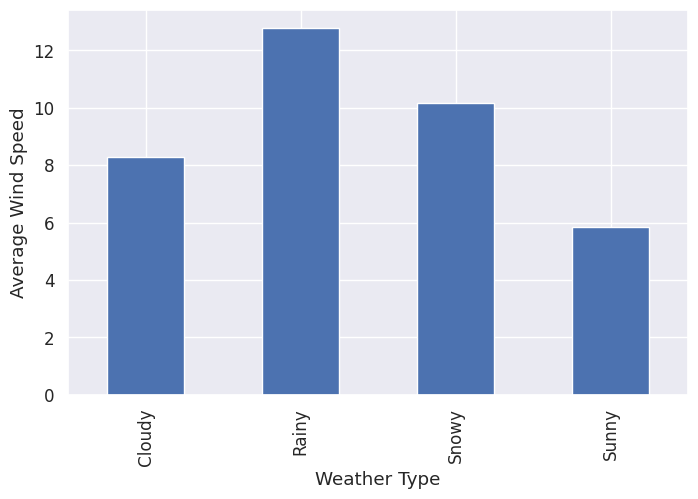

In [ ]:
avg_wind = df_clean.groupby("Weather Type")["Wind Speed"].mean()

avg_wind.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Average Wind Speed")

plt.show()

# 3. Logistic Regression & Model Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.9550898203592815


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistic,target_names=label_encoder.classes_))

              precision    recall  f1-score   support

      Cloudy       0.94      0.93      0.94       599
       Rainy       0.93      0.94      0.93       566
       Snowy       0.98      0.99      0.98       580
       Sunny       0.98      0.96      0.97       593

    accuracy                           0.96      2338
   macro avg       0.96      0.96      0.96      2338
weighted avg       0.96      0.96      0.96      2338



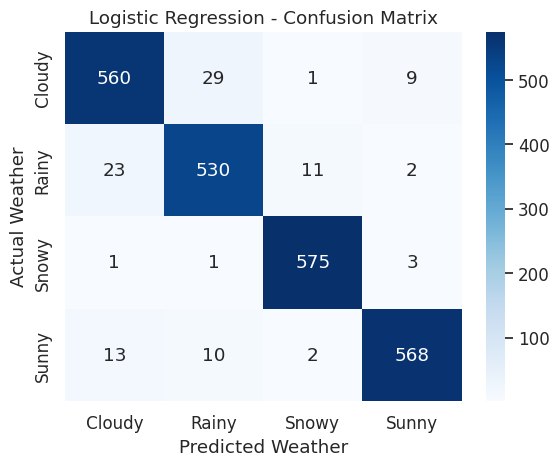

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_logistic)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Weather")
plt.ylabel("Actual Weather")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# 4. Gaussian Naive *Bayes* & Model Evaluation

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test_scaled)

In [ ]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Gaussian NB Accuracy:", accuracy_nb)

Gaussian NB Accuracy: 0.9234388366124893


In [ ]:
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      Cloudy       0.96      0.85      0.90       599
       Rainy       0.90      0.89      0.90       566
       Snowy       0.93      0.99      0.96       580
       Sunny       0.91      0.96      0.94       593

    accuracy                           0.92      2338
   macro avg       0.92      0.92      0.92      2338
weighted avg       0.92      0.92      0.92      2338



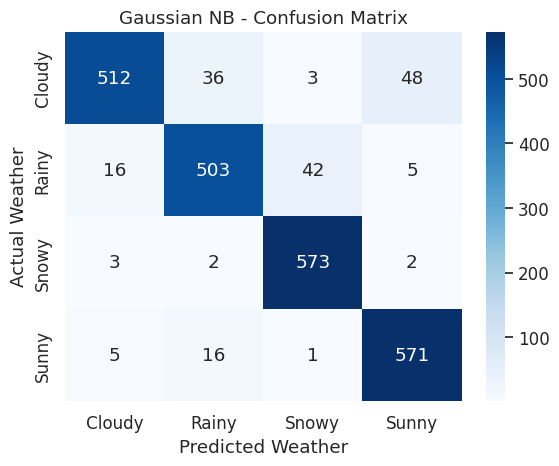

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Weather")
plt.ylabel("Actual Weather")
plt.title("Gaussian NB - Confusion Matrix")
plt.show()

# 5. SVM & Model Evaluation

In [ ]:
from sklearn.svm import SVC
svm_linear = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

accuracy_linear = accuracy_score(
    y_test,
    y_pred_linear
)

print("SVM Linear Accuracy:", accuracy_linear)

SVM Linear Accuracy: 0.9619332763045337


In [ ]:
print(classification_report(
    y_test,
    y_pred_linear,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      Cloudy       0.94      0.94      0.94       599
       Rainy       0.94      0.96      0.95       566
       Snowy       0.99      0.99      0.99       580
       Sunny       0.98      0.96      0.97       593

    accuracy                           0.96      2338
   macro avg       0.96      0.96      0.96      2338
weighted avg       0.96      0.96      0.96      2338



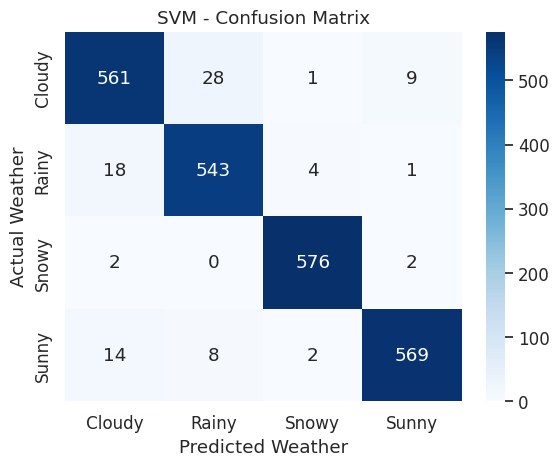

In [ ]:
cm = confusion_matrix(y_test, y_pred_linear)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Weather")
plt.ylabel("Actual Weather")
plt.title("SVM - Confusion Matrix")
plt.show()

In [ ]:
svm_rbf = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

accuracy_rbf = accuracy_score(
    y_test,
    y_pred_rbf
)

print("SVM RBF Accuracy:", accuracy_rbf)

SVM RBF Accuracy: 0.9670658682634731


In [ ]:
print(classification_report(
    y_test,
    y_pred_rbf,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      Cloudy       0.94      0.96      0.95       599
       Rainy       0.95      0.96      0.96       566
       Snowy       0.99      0.99      0.99       580
       Sunny       0.98      0.96      0.97       593

    accuracy                           0.97      2338
   macro avg       0.97      0.97      0.97      2338
weighted avg       0.97      0.97      0.97      2338



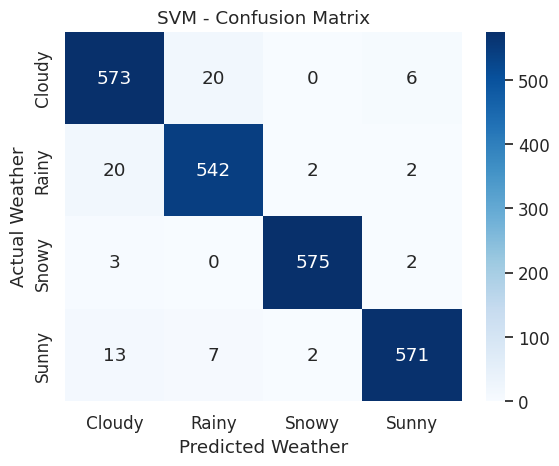

In [ ]:
cm = confusion_matrix(y_test, y_pred_rbf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Weather")
plt.ylabel("Actual Weather")
plt.title("SVM - Confusion Matrix")
plt.show()

# comparison between the three models

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    average='weighted',
    zero_division=1
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    average='weighted',
    zero_division=1
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average='weighted',
    zero_division=1
)


precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average='weighted',
    zero_division=1
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average='weighted',
    zero_division=1
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average='weighted',
    zero_division=1
)

precision_linear = precision_score(
    y_test,
    y_pred_linear,
    average='weighted',
    zero_division=1
)

recall_linear = recall_score(
    y_test,
    y_pred_linear,
    average='weighted',
    zero_division=1
)

f1_linear = f1_score(
    y_test,
    y_pred_linear,
    average='weighted',
    zero_division=1
)

precision_rbf = precision_score(
    y_test,
    y_pred_rbf,
    average='weighted',
    zero_division=1
)

recall_rbf = recall_score(
    y_test,
    y_pred_rbf,
    average='weighted',
    zero_division=1
)

f1_rbf = f1_score(
    y_test,
    y_pred_rbf,
    average='weighted',
    zero_division=1
)

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Gaussian NB',
        'SVM Linear',
        'SVM RBF'
    ],
    'Accuracy': [
        accuracy_logistic,
        accuracy_nb,
        accuracy_linear,
        accuracy_rbf
    ],
    'Precision': [
        precision_logistic,
        precision_nb,
        precision_linear,
        precision_rbf
    ],
    'Recall': [
        recall_logistic,
        recall_nb,
        recall_linear,
        recall_rbf
    ],
    'F1-Score': [
        f1_logistic,
        f1_nb,
        f1_linear,
        f1_rbf
    ]
})

print("Model Performance Comparison")
print(comparison)

Model Performance Comparison
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.955090   0.955135  0.955090  0.955073
1          Gaussian NB  0.923439   0.924339  0.923439  0.922735
2           SVM Linear  0.961933   0.962091  0.961933  0.961952
3              SVM RBF  0.967066   0.967288  0.967066  0.967133


## by comparing we found that the strongest model is : **SVM_RBF Model**

# User Interface with the strongest model

In [ ]:
!pip install gradio
import gradio as gr

In [ ]:
def predict_weather(
    temperature,
    humidity,
    wind_speed,
    precipitation,
    cloud_cover,
    pressure,
    uv_index,
    season,
    visibility,
    location
):

    new_data = pd.DataFrame({
        "Temperature": [temperature],
        "Humidity": [humidity],
        "Wind Speed": [wind_speed],
        "Precipitation (%)": [precipitation],
        "Cloud Cover": [cloud_cover],
        "Atmospheric Pressure": [pressure],
        "UV Index": [uv_index],
        "Season": [season],
        "Visibility (km)": [visibility],
        "Location": [location]
    })


    new_data = pd.get_dummies(new_data,drop_first=True)

    new_data = new_data.reindex(columns=X.columns, fill_value=0)

    new_data_scaled = pd.DataFrame(
        scaler.transform(new_data),
        columns=X.columns
    )

    prediction = svm_rbf.predict(new_data_scaled)

    predicted_weather = label_encoder.inverse_transform(prediction)

    return predicted_weather[0]

In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict_weather,

    inputs=[
        gr.Number(label="🌡️ Temperature"),
        gr.Number(label="💧 Humidity"),
        gr.Number(label="💨 Wind Speed"),
        gr.Number(label="🌧️ Precipitation (%)"),

        gr.Dropdown(
            ["clear", "partly cloudy", "overcast"],
            label="☁️ Cloud Cover"
        ),

        gr.Number(label="🎈 Atmospheric Pressure"),
        gr.Number(label="☀️ UV Index"),

        gr.Dropdown(
            ["Winter", "Spring", "Summer", "Autumn"],
            label="🍂 Season"
        ),

        gr.Number(label="👁️ Visibility (km)"),

        gr.Dropdown(
            ["inland", "mountain", "coastal"],
            label="📍 Location"
        )
    ],

    outputs=gr.Textbox(
        label="🔮 Predicted Weather"
    ),

    title="🌦️ Weather Prediction System",

    description=(
        "Enter the current weather conditions below "
        "and the Machine Learning model will predict the weather type."
    ),

   theme=gr.themes.Soft()
)

interface.launch()

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning:

The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.



It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5e82437b583c925e6b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
